In [1]:
from single import return_omega_j, get_v, get_M
import numpy as np
import matplotlib.pyplot as plt

In [2]:
l = 25
c = 300

ni = [2, 2]
di = [1, 1]
d12 = 2
n_points = 100

Pi = np.array([10, 100])
E = 3.5e10
J = 3.8349
mu = 18358
j_end = 10

In [3]:
omega = np.pi*c/l
v0i = Pi*l**3/(np.pi**4*E*J)
M0i = Pi*l/4
alpha = omega/return_omega_j(1, E, J, l, mu)
print(f'alpha={alpha:.2f}')

# Settings plot
colors = ['red', 'blue']

nx = 1001
dx = l/(nx-1)
x = np.linspace(0, l, nx)

if ni[1] > 0:
    dtot = (ni[0]-1)*di[0] + d12 +  (ni[1]-1)*di[1]
else:
    dtot = (ni[0]-1)*di[0]

T_tot = (l+dtot)/c

alpha=0.88


# Create time array
- for now, all forces must enter before exiting (check with real scenarios)

In [4]:
t0 = 0
entering = []

# Stack lists
# each list(enter) represents a Pi
for j in range(0, len(Pi)):
    enter = [t0]
    for i in range(0, ni[j]-1):
        t = t0 + di[j]/c
        enter.append(t)
        t0 = t
    t0 += d12/c
    entering.append(enter)

t0 = l/c
exiting = []
for j in range(0, len(Pi)):
    exit = [t0]
    for i in range(0, ni[j]-1):
        t = t0 + di[j]/c
        exit.append(t)
        t0 = t
    t0 += d12/c
    exiting.append(exit)

# time array cannot be built correctly if max(entering) > min(exiting) 
if max(entering) > min(exiting):
    raise SystemExit("Time array cannot be built properly")
"""
plt.figure()
plt.plot(t_single, vi[0][x.shape[0]//2, :])
plt.plot(t_single, vi[1][x.shape[0]//2, :])
plt.show()
"""
t = []
idxs_entering = []
for i in range(len(entering)):
    t_frame = np.linspace(entering[i][0], entering[i][1], n_points)
    t.append(t_frame)
t_end = t[0][-1]
t_trans = np.linspace(t_end, t_end + d12/c, n_points)
t.insert(1, t_trans)
t_tot = np.array(t).reshape(-1)
idxs_entering = ((0, n_points), (n_points*2, n_points*3-1))

t_enex = np.linspace(t_tot[-1], exiting[0][0], n_points)
t_tot = np.concatenate((t_tot, t_enex))
t = []
for i in range(len(exiting)):
    t_frame = np.linspace(exiting[i][0], exiting[i][1], n_points)
    t.append(t_frame)
t_end = t[0][-1]
t_trans = np.linspace(t_end, t_end + d12/c, n_points)
t.insert(1, t_trans)
t = np.array(t).reshape(-1)
idxs_exiting = (np.array([[0, n_points],
    [n_points*2, n_points*3-1]])
    + idxs_entering[-1][-1] + 1 + n_points)
idxs_exiting = idxs_exiting.tolist()
idxs_exiting = tuple(idxs_exiting)
idxs = [idxs_entering, idxs_exiting]

t_tot = np.concatenate((t_tot, t))

- add free response of the beam when forces are exiting

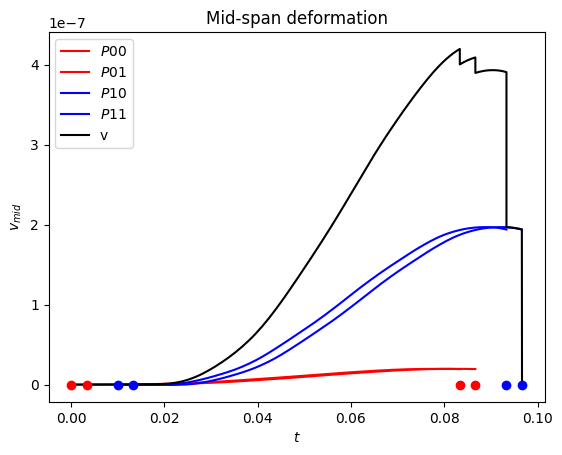

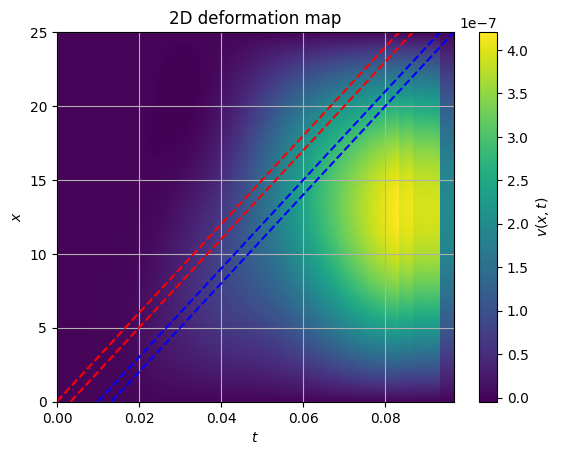

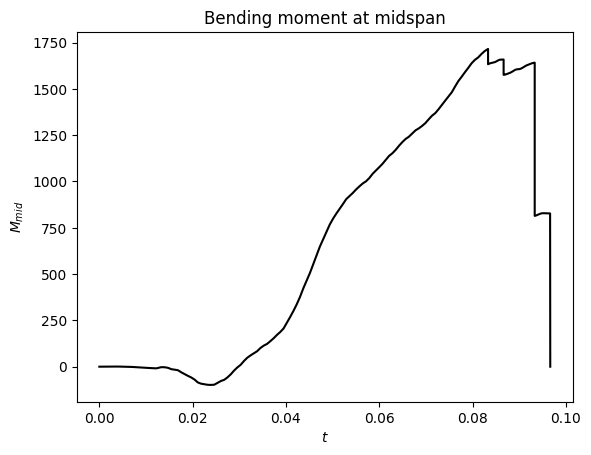

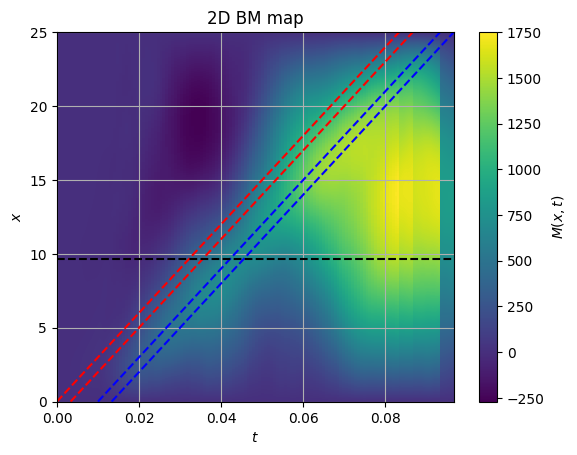

In [5]:
v = np.zeros((x.shape[0], t_tot.shape[0]))
plt.figure()
for j in range(len(entering)):
    color = colors[j]
    for i in range(len(entering[0])):
        t0 = t_tot[idxs[0][j][i]]
        t_single = t_tot[idxs[0][j][i]:idxs[1][j][i]] - t0
        vi = get_v(x, t_single, j_end, alpha, omega, v0i[j], l, E, J, mu)
        """
        plt.figure()
        plt.plot(t_single, vi[vi.shape[0]//2, :])
        plt.show()
        """
        vmid = vi[vi.shape[0]//2, :]
        plt.plot(t_single + t0, vmid, label=f'$P{j}{i}$', color=color)
        v[:, idxs[0][j][i]:idxs[1][j][i]] += vi
plt.plot(t_tot, v[v.shape[0]//2, :], label='v', color='black')
plt.xlabel(r'$t$')
plt.ylabel(r'$v_{mid}$')
plt.title('Displacement at midspan')
plt.legend()
# Plot entering for P1
for j in range(len(idxs)):
    color = colors[j]
    for i in range(len(idxs[i])):
        plt.plot(t_tot[idxs[0][j][i]], 0, 'o', color=color)
        plt.plot(t_tot[idxs[1][j][i]], 0, 'o', color=color)
plt.title('Mid-span deformation')
plt.xlabel('$t$')
plt.ylabel(r'$v_{mid}$')
plt.show()

X, T = np.meshgrid(x, t_tot)
# Contour plot x-t
plt.figure()
pcm = plt.pcolormesh(T.T, x.T, v, shading='auto', cmap='viridis')

# plot forces lines
for j in range(len(entering)):
    color = colors[j]
    for i in range(len(entering[0])):
        ti = t_tot[idxs[0][j][i]:idxs[1][j][i]]
        plt.plot(ti, c*(ti-ti[0]), '--', color=color)

plt.colorbar(pcm, label=r'$v(x,t)$')
plt.xlabel(r'$t$')
plt.ylabel(r'$x$')
plt.grid(True)
plt.title('2D deformation map')
plt.show()

# Plot bending moment
M = np.zeros((x.shape[0], t_tot.shape[0]))
plt.figure()
for j in range(len(entering)):
    color = colors[j]
    for i in range(len(entering[0])):
        t0 = t_tot[idxs[0][j][i]]
        t_single = t_tot[idxs[0][j][i]:idxs[1][j][i]] - t0
        Mi = get_M(x, t_single, j_end, alpha, omega, M0i[j], l, E, J, mu)
        """
        plt.figure()
        plt.plot(t_single, Mi[Mi.shape[0]//2, :])
        plt.show()
        """
        Mmid = Mi[Mi.shape[0]//2, :]
        M[:, idxs[0][j][i]:idxs[1][j][i]] += Mi

Mmid = M[M.shape[0]//2, :]
plt.plot(t_tot, Mmid, label='M', color='black')
plt.title('Bending moment at midspan')
plt.xlabel(r'$t$')
plt.ylabel(r'$M_{mid}$')
plt.show()

X, T = np.meshgrid(x, t_tot)
# Contour plot x-t
plt.figure()

pcm = plt.pcolormesh(T.T, x.T, M, shading='auto', cmap='viridis')

# plot forces lines
for j in range(len(entering)):
    color = colors[j]
    for i in range(len(entering[0])):
        ti = t_tot[idxs[0][j][i]:idxs[1][j][i]]
        plt.plot(ti, c*(ti-ti[0]), '--', color=color)

loct = np.argmax(M, axis=0)
locx = np.argmax(loct)
COP = locx * dx
plt.plot(t_tot, np.ones_like(t_tot)*COP, '--k', label='COP')

plt.colorbar(pcm, label=r'$M(x,t)$')
plt.xlabel(r'$t$')
plt.ylabel(r'$x$')
plt.grid(True)
plt.title('2D BM map')
plt.show()